# Demo 2: Multi-Symbol Autoencoder vs 16-QAM
## Kenh: Rayleigh + PA Nonlinearity + CFO + AWGN

### Mo hinh kenh
```
x[n] -> PA(x[n]) -> h*PA(x[n]) -> h*PA(x[n])*exp(j*2pi*df*n*Ts) -> + noise -> y[n]
```

**CFO** (Carrier Frequency Offset) gay **quay pha lien tuc** tren constellation:
- Symbol thu n bi quay them goc `2pi*df*n*Ts`
- Voi L=4 symbols/block, symbol cuoi bi quay gap 3 lan symbol thu 2

**Tai sao ANN co loi the?**
- 16-QAM can bo uoc luong CFO rieng biet -> phuc tap, khong hoan hao
- ANN decoder nhin ca block L symbols -> **tu hoc uoc luong + bu CFO** end-to-end
- Ket hop Rayleigh + PA + CFO tao distortion phuc tap ma ANN xu ly tot hon

### BER Evaluation: Real Decoder
- AE: Input -> Encoder -> PA -> Rayleigh -> CFO -> AWGN -> **Decoder that** -> Dem loi bit
- QAM: Input -> QAM map -> PA -> Rayleigh -> CFO -> AWGN(**cung noise**) -> ZF+slicer -> Dem loi bit

In [122]:
import sys, os
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [123]:
import importlib
import cfo_multisymbol as cfo
importlib.reload(cfo)

<module 'cfo_multisymbol' from 'e:\\K31\\ChannelCodeStudio\\AE-Modulation\\Demo2\\cfo_multisymbol.py'>

## 1. Tham so he thong

In [124]:
# ============================================================
#  THAM SO HE THONG — Thay doi o day truoc khi chay
# ============================================================

# --- Modulation ---
M = 16          # So diem constellation (16-QAM equivalent)
L = 4           # So symbols/block (multi-symbol)

# --- PA (Power Amplifier) ---
A_SAT    = 1.2  # Diem bao hoa PA (Rapp model)
P_RAPP   = 3    # Do sac cua dac tuyen bao hoa
ALPHA_PM = 0.08 # He so AM/PM (phi = alpha * r^2)
BETA_PM  = 0.0  # He so phi tuyen AM/PM bac cao

# --- CFO ---
CFO_MAX  = 0.03 # CFO max cho training (normalized df*Ts)

print(f'System: M={M}, L={L} symbols/block')
print(f'Bits/block: {L * int(np.log2(M))} bits')
print(f'PA: A_sat={A_SAT}, p={P_RAPP}, alpha_pm={ALPHA_PM}, beta_pm={BETA_PM}')
print(f'CFO training range: +/-{CFO_MAX}')

System: M=16, L=4 symbols/block
Bits/block: 16 bits
PA: A_sat=1.2, p=3, alpha_pm=0.08, beta_pm=0.0
CFO training range: +/-0.03


## 2. Minh hoa hieu ung CFO tren 16-QAM

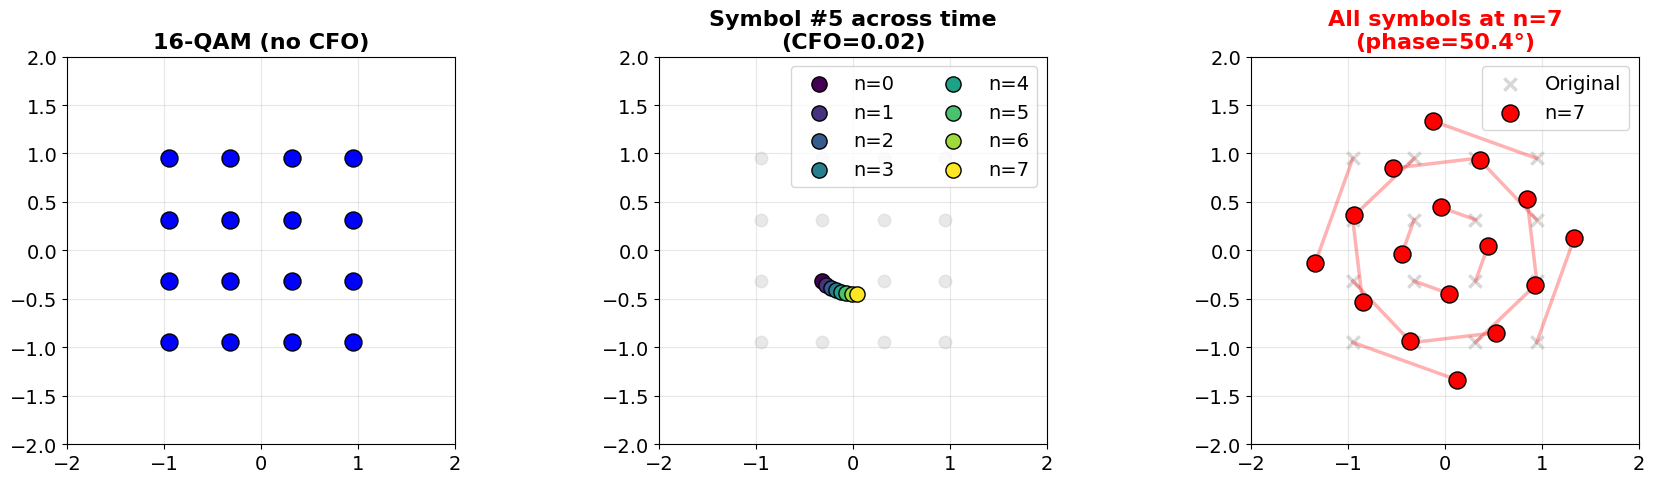

In [125]:
fig = cfo.plot_cfo_effect(cfo_val=0.02, L=8)
plt.show()

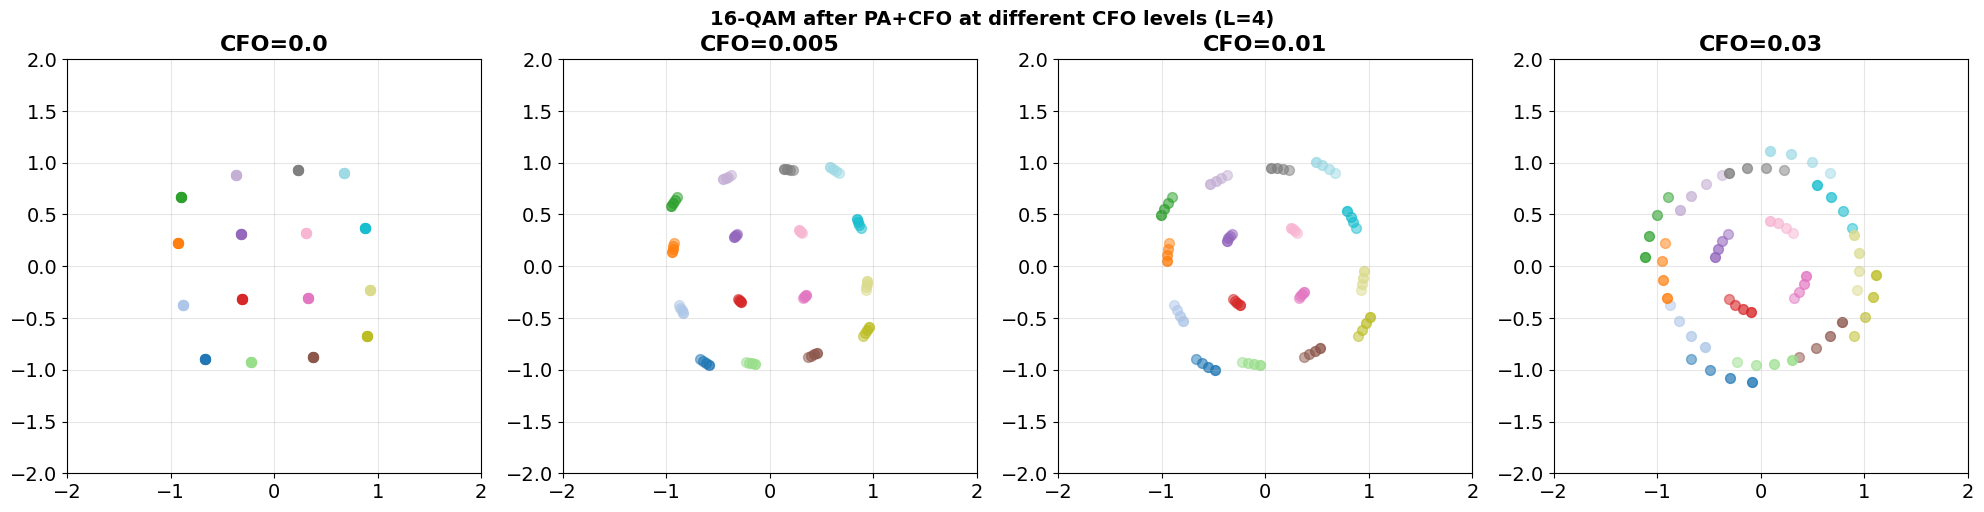

In [126]:
import matplotlib.pyplot as plt

# Show CFO effect at different severity levels
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
const = cfo.qam16_constellation()

for ax, cfo_val in zip(axes, [0.0, 0.005, 0.01, 0.03]):
    L_show = 4
    n_idx = np.arange(L_show).reshape(1, L_show)
    phase = 2.0 * np.pi * cfo_val * n_idx

    # Apply PA + CFO to all symbols
    const_pa = cfo.apply_pa_numpy(const, A_SAT, P_RAPP, ALPHA_PM, BETA_PM)

    colors = plt.cm.tab20(np.linspace(0, 1, 16))
    for sym in range(L_show):
        rotated = const_pa * np.exp(1j * phase[0, sym])
        for i in range(16):
            ax.scatter(rotated[i].real, rotated[i].imag,
                      c=[colors[i]], s=50, alpha=0.5+0.1*sym)

    ax.set_title(f'CFO={cfo_val}', fontweight='bold')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.suptitle('16-QAM after PA+CFO at different CFO levels (L=4)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Build & Train Autoencoder

In [127]:
# ============================================================
#  THAM SO TRAINING — Thay doi o day truoc khi train
# ============================================================

BATCH_SIZE = 4096   # Batch size cho training
USE_CUSTOM_LOSS = True  # True: custom loss, False: categorical_crossentropy

print(f'Batch size: {BATCH_SIZE}')
print(f'Custom loss: {USE_CUSTOM_LOSS}')

Batch size: 4096
Custom loss: True


In [128]:
logger = cfo.init_logger('train_cfo2.txt')
logger.log_params(M, L, A_SAT, P_RAPP, ALPHA_PM, BETA_PM, CFO_MAX, BATCH_SIZE)

encoder, autoencoder = cfo.build_multisymbol_autoencoder_light(
    M=M, L=L, a_sat=A_SAT, p_rapp=P_RAPP,
    alpha_pm=ALPHA_PM, beta_pm=BETA_PM)

logger.log_model(encoder)
logger.log_model(autoencoder)
autoencoder.summary()

[10:51:05] ======================================================================
[10:51:05]   Demo2: Multi-Symbol CFO+PA+AWGN — Training Log
[10:51:05]   Started: 2026-04-24 10:51:05
[10:51:05] ======================================================================
[10:51:05]   M=16, L=4 symbols/block
[10:51:05]   A_sat=1.2, p_rapp=3
[10:51:05]   alpha_pm=0.08, beta_pm=0.0
[10:51:05]   CFO_max=0.03 (normalized Δf·Ts)
[10:51:05]   batch_size=4096
[10:51:05]   Encoder: 3,234 params
[10:51:05]   Autoencoder: 251,746 params
Model: "Autoencoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 msg_input (InputLayer)         [(None, 4, 16)]      0           []                               
                                                                                                  
 enc_td1 (TimeDistributed)      (None, 4, 64)        1088

In [129]:
hist = cfo.train_curriculum_cfo_light(
    autoencoder, encoder=encoder,
    M=M, L=L, a_sat=A_SAT,
    batch_size=BATCH_SIZE,
    logger=logger, verbose=0,
    use_custom_loss=USE_CUSTOM_LOSS
)

[10:51:05]   [LIGHT] Total phases: 4, epochs: 105
[10:51:05]   [LIGHT] Total samples: 141,557,760
[10:51:05]   Custom loss: True
[10:51:06] 
[10:51:06] ============================================================
[10:51:06]   [LIGHT] Phase 1: High SNR, tiny CFO
[10:51:06]   SNR: 14-35 dB | CFO_max: 0.005
[10:51:06]   Steps: 256 | Epochs: 30 | LR: 0.002
[10:51:06] ============================================================
[10:51:15]   Ep   1 | loss=0.6892 acc=0.7966 | v_loss=0.2002 v_acc=0.9455 | lr=2.00e-03
[10:51:23]   Ep   2 | loss=0.1383 acc=0.9588 | v_loss=0.1378 v_acc=0.9570 | lr=2.00e-03
[10:51:30]   Ep   3 | loss=0.1239 acc=0.9610 | v_loss=0.1151 v_acc=0.9640 | lr=2.00e-03
[10:51:38]   Ep   4 | loss=0.1170 acc=0.9621 | v_loss=0.1074 v_acc=0.9656 | lr=2.00e-03
[10:51:45]   Ep   5 | loss=0.1116 acc=0.9629 | v_loss=0.1110 v_acc=0.9641 | lr=2.00e-03
[10:51:52]   Ep   6 | loss=0.1069 acc=0.9636 | v_loss=0.0997 v_acc=0.9651 | lr=2.00e-03
[10:51:59]   Ep   7 | loss=0.1042 acc=0.9640 

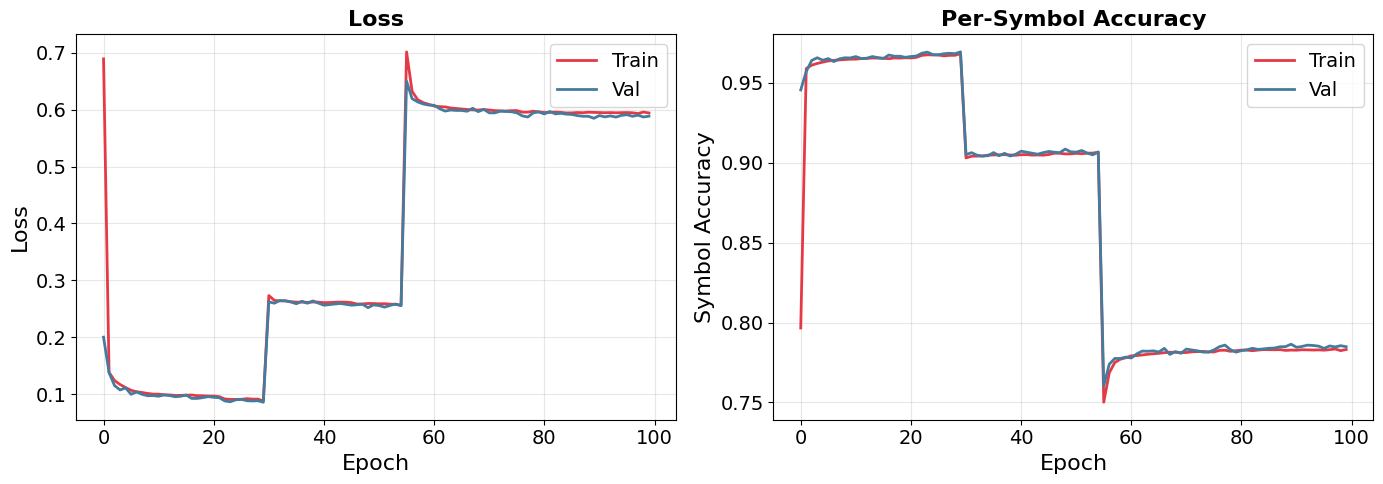

In [130]:
fig = cfo.plot_history(hist)
plt.show()

In [131]:
logger.log_constellation(encoder, M, L)

[11:04:04]   Constellation:
[11:04:04]     Avg amp: 0.7095
[11:04:04]     Max amp: 1.1504
[11:04:04]     Min dist: 0.3379
[11:04:04]     PAPR: 3.35 dB


## 4. Learned Constellation

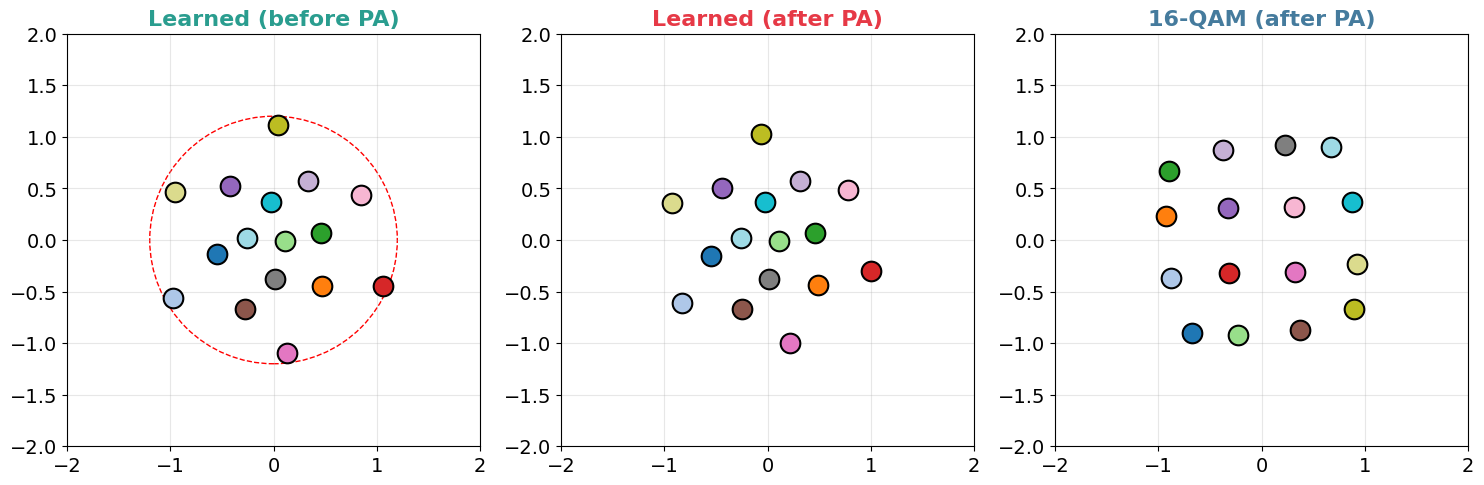

In [132]:
fig = cfo.plot_constellation_learned(
    encoder, M=M, L=L, a_sat=A_SAT,
    p_rapp=P_RAPP, alpha_pm=ALPHA_PM, beta_pm=BETA_PM)
plt.show()

## 5. BER Evaluation

### Pipeline danh gia BER:
```
AE:  Input -> Encoder(neural) -> PA -> Rayleigh -> CFO -> AWGN -> Decoder(neural) -> Dem loi bit
QAM: Input -> QAM map          -> PA -> Rayleigh -> CFO -> AWGN(cung noise) -> ZF+slicer -> Dem loi bit
```

In [ ]:
# ============================================================
#  THAM SO DANH GIA BER — Thay doi o day truoc khi chay
# ============================================================

# --- BER vs SNR (section 5a) ---
SNR_EVAL = np.arange(0, 36)       # Dai SNR danh gia (dB)

# --- Cac gia tri CFO danh gia (dung cho CA 2 section 5a va 5b) ---
CFO_VALUES = [0.01, 0.005, 0.01, 0.02, 0.03]

# --- BER vs CFO (section 5b) ---
SNR_TEST_VALS = [12, 15, 18]      # Cac muc SNR co dinh cho BER vs CFO

# --- Monte Carlo ---
MIN_ERRORS = 200                  # So loi toi thieu
MAX_SYMBOLS = 5_000_000           # So symbols toi da moi diem SNR
MC_BATCH = 200_000                # Batch size Monte Carlo
N_EVAL = 100_000                  # So symbols moi trial (BER vs CFO)
N_TRIALS = 3                     # So trials trung binh

# --- PA cho evaluation (co the khac voi training) ---
EVAL_A_SAT    = A_SAT
EVAL_P_RAPP   = P_RAPP
EVAL_ALPHA_PM = ALPHA_PM
EVAL_BETA_PM  = BETA_PM

print(f'SNR range: {SNR_EVAL[0]}-{SNR_EVAL[-1]} dB ({len(SNR_EVAL)} points)')
print(f'CFO values: {CFO_VALUES}')
print(f'SNR test vals (BER vs CFO): {SNR_TEST_VALS}')
print(f'Monte Carlo: min_errors={MIN_ERRORS}, max_symbols={MAX_SYMBOLS:,}')
print(f'Eval PA: A_sat={EVAL_A_SAT}, p={EVAL_P_RAPP}, alpha={EVAL_ALPHA_PM}')

SNR range: 0-35 dB (36 points)
CFO values: [0.0, 0.005, 0.01, 0.02, 0.03]
SNR test vals (BER vs CFO): [12, 15, 18]
Monte Carlo: min_errors=200, max_symbols=5,000,000
Eval PA: A_sat=1.2, p=3, alpha=0.08


### 5a. BER vs SNR - So sanh fair (cung input, cung noise)

[11:04:04] 
[11:04:04] ======================================================================
[11:04:04]   BER Evaluation: Real Decoder - Fair Comparison (same noise)
[11:04:04]   AE: encoder -> PA -> Rayleigh -> CFO -> AWGN -> decoder -> bits
[11:04:04]   QAM: map -> PA -> Rayleigh -> CFO -> AWGN -> ZF+slicer -> bits
[11:04:04] ======================================================================
[11:04:04] 
=== CFO = 0.0 ===
[11:04:04] Fair comparison: AE (real decoder) vs QAM baselines...
  PA: Rapp p=3, A_sat=1.2
  PA AM/PM: alpha=0.08, beta=0.0
  CFO: 0.0000 (normalized)
  Channel: PA + Rayleigh + CFO + AWGN

  SNR   0.0 dB | AE 3.788e-01 (1,212,241) | QAM+ZF 3.016e-01 (965,164) | Gain -0.99 dB | 200,000 syms
  SNR   1.0 dB | AE 3.616e-01 (1,157,275) | QAM+ZF 2.847e-01 (911,050) | Gain -1.04 dB | 200,000 syms
  SNR   2.0 dB | AE 3.436e-01 (1,099,648) | QAM+ZF 2.666e-01 (853,068) | Gain -1.10 dB | 200,000 syms
  SNR   3.0 dB | AE 3.239e-01 (1,036,578) | QAM+ZF 2.481e-01 (794,059) 

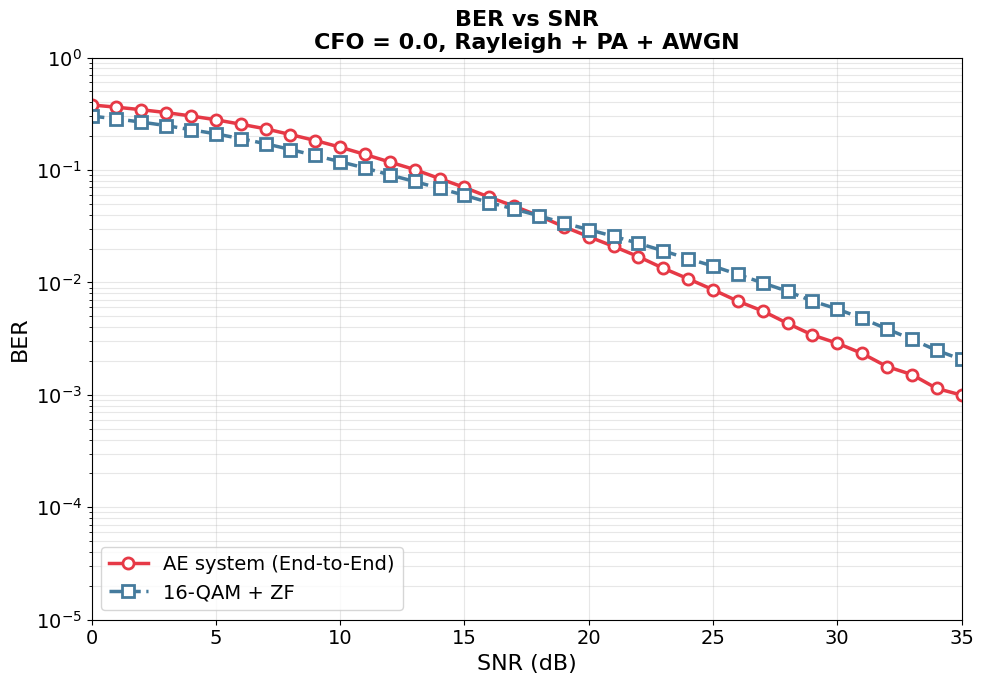

[11:04:36] 
=== CFO = 0.005 ===
[11:04:36] Fair comparison: AE (real decoder) vs QAM baselines...
  PA: Rapp p=3, A_sat=1.2
  PA AM/PM: alpha=0.08, beta=0.0
  CFO: 0.0050 (normalized)
  Channel: PA + Rayleigh + CFO + AWGN

  SNR   0.0 dB | AE 3.797e-01 (1,215,183) | QAM+ZF 3.047e-01 (975,158) | Gain -0.96 dB | 200,000 syms
  SNR   1.0 dB | AE 3.631e-01 (1,161,934) | QAM+ZF 2.883e-01 (922,601) | Gain -1.00 dB | 200,000 syms
  SNR   2.0 dB | AE 3.454e-01 (1,105,303) | QAM+ZF 2.711e-01 (867,363) | Gain -1.05 dB | 200,000 syms
  SNR   3.0 dB | AE 3.250e-01 (1,039,931) | QAM+ZF 2.528e-01 (809,064) | Gain -1.09 dB | 200,000 syms
  SNR   4.0 dB | AE 3.041e-01 (973,188) | QAM+ZF 2.341e-01 (749,139) | Gain -1.14 dB | 200,000 syms
  SNR   5.0 dB | AE 2.821e-01 (902,742) | QAM+ZF 2.168e-01 (693,688) | Gain -1.14 dB | 200,000 syms
  SNR   6.0 dB | AE 2.573e-01 (823,500) | QAM+ZF 1.976e-01 (632,307) | Gain -1.15 dB | 200,000 syms
  SNR   7.0 dB | AE 2.323e-01 (743,516) | QAM+ZF 1.788e-01 (572,064) 

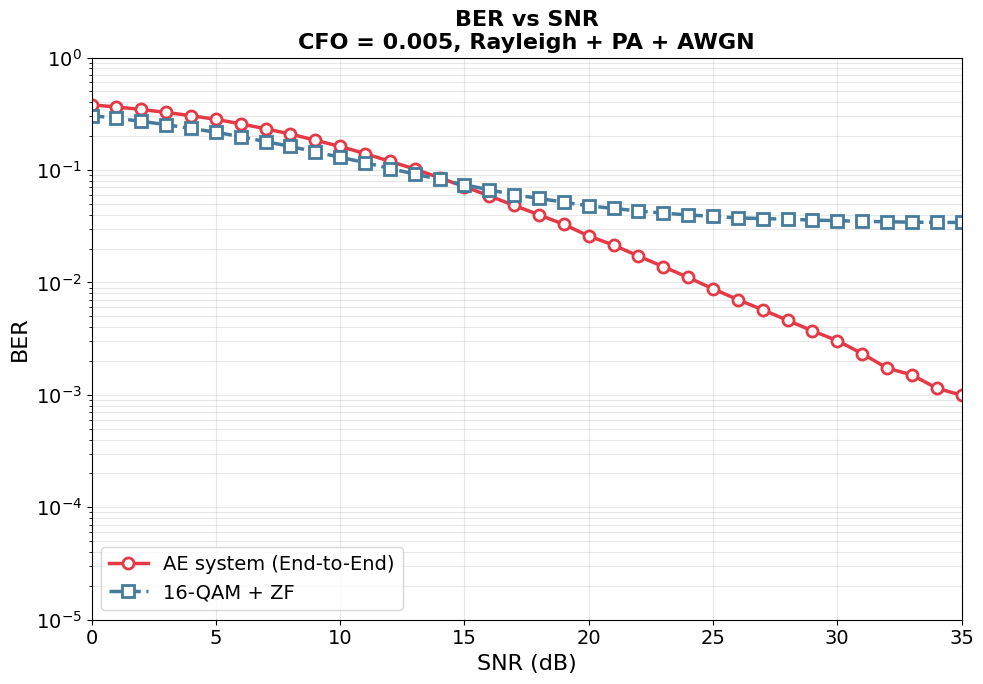

[11:05:07] 
=== CFO = 0.01 ===
[11:05:07] Fair comparison: AE (real decoder) vs QAM baselines...
  PA: Rapp p=3, A_sat=1.2
  PA AM/PM: alpha=0.08, beta=0.0
  CFO: 0.0100 (normalized)
  Channel: PA + Rayleigh + CFO + AWGN

  SNR   0.0 dB | AE 3.816e-01 (1,221,193) | QAM+ZF 3.078e-01 (985,052) | Gain -0.93 dB | 200,000 syms
  SNR   1.0 dB | AE 3.668e-01 (1,173,899) | QAM+ZF 2.933e-01 (938,444) | Gain -0.97 dB | 200,000 syms
  SNR   2.0 dB | AE 3.487e-01 (1,115,927) | QAM+ZF 2.770e-01 (886,250) | Gain -1.00 dB | 200,000 syms
  SNR   3.0 dB | AE 3.299e-01 (1,055,657) | QAM+ZF 2.606e-01 (833,943) | Gain -1.02 dB | 200,000 syms


In [ ]:
logger.log('')
logger.log('=' * 70)
logger.log('  BER Evaluation: Real Decoder - Fair Comparison (same noise)')
logger.log('  AE: encoder -> PA -> Rayleigh -> CFO -> AWGN -> decoder -> bits')
logger.log('  QAM: map -> PA -> Rayleigh -> CFO -> AWGN -> ZF+slicer -> bits')
logger.log('=' * 70)

for cfo_val in CFO_VALUES:
    logger.log(f'\n=== CFO = {cfo_val} ===')
    logger.log('Fair comparison: AE (real decoder) vs QAM baselines...')

    # Fair Monte Carlo BER: same input, same noise
    ber_ae, ber_qam_nc, _, stats = cfo.compare_ber_cfo(
        encoder, autoencoder, SNR_EVAL, cfo_val,
        M=M, L=L,
        a_sat=EVAL_A_SAT, p_rapp=EVAL_P_RAPP,
        alpha_pm=EVAL_ALPHA_PM, beta_pm=EVAL_BETA_PM,
        min_errors=MIN_ERRORS, max_symbols=MAX_SYMBOLS,
        batch_size=MC_BATCH, verbose=True)

    # Log table
    logger.log_ber_table(SNR_EVAL, {
        'AE(real dec)': ber_ae,
        'QAM+ZF': ber_qam_nc,
    })

    # Plot
    fig = cfo.plot_ber_vs_snr(SNR_EVAL, {
        'AE system (End-to-End)': ber_ae,
        '16-QAM + ZF': ber_qam_nc,
    }, title_suffix=f'\nCFO = {cfo_val}, Rayleigh + PA + AWGN')
    plt.show()

### 5b. BER vs CFO tai SNR co dinh

Danh gia BER khi CFO thay doi, su dung **decoder that**.

In [ ]:
logger.log('')
logger.log('--- BER Evaluation: BER vs CFO (Real Decoder) ---')

for snr_val in SNR_TEST_VALS:
    logger.log(f'\n=== SNR = {snr_val} dB ===')

    # AE with real decoder
    logger.log('Evaluating AE (real decoder)...')
    ber_ae_cfo = cfo.eval_ae_ber_vs_cfo(
        encoder, autoencoder, snr_val, CFO_VALUES,
        M=M, L=L, N=N_EVAL, trials=N_TRIALS,
        a_sat=EVAL_A_SAT, p_rapp=EVAL_P_RAPP,
        alpha_pm=EVAL_ALPHA_PM, beta_pm=EVAL_BETA_PM)

    # QAM baseline (no CFO compensation)
    logger.log('Evaluating QAM baseline (no comp)...')
    ber_nocomp = []
    for c in CFO_VALUES:
        b1 = cfo.qam16_ber_cfo_nocomp(
            [snr_val], c, L=L, N=200_000,
            a_sat=EVAL_A_SAT, p_rapp=EVAL_P_RAPP,
            alpha_pm=EVAL_ALPHA_PM, beta_pm=EVAL_BETA_PM)[0]
        ber_nocomp.append(b1)
    ber_nocomp = np.array(ber_nocomp)

    fig = cfo.plot_ber_vs_cfo(CFO_VALUES, {
        'AE system (End-to-End)': ber_ae_cfo,
        '16-QAM + ZF (no CFO comp)': ber_nocomp,
    }, snr_val=snr_val)
    plt.show()

## 6. Ket luan

In [ ]:
logger.log_finish()
print('\nDemo2 complete! Log saved to train_cfo2.txt')